# *****Hint Timer Model*****

In [1]:
# Import library yang dibutuhkan
import numpy as np
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    KFold, cross_val_score, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproduksi hasil
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. **Simulasi Data Pemain**

Membuat data sintetis yang mereplikasi distribusi realistis dari variabel yang dikumpulkan game. Empat profil pemain dimodelkan (`Speedrunner`, `Careful`, `Learner`, `Struggling`) agar distribusi fitur mencerminkan keberagaman pemain nyata.


In [2]:
# Simulasi Data Pemain Sintetis
# Setiap baris = satu sesi game, field sesuai struktur player_data.json

def _simulate_sessions(n_players=120, sessions_per_player=(5, 30)):
    rng   = np.random.default_rng(RANDOM_STATE)
    DIFF  = ["Easy", "Normal", "Hard"]
    GRID  = [2, 3]   # 4x4 (grid_size=2) or 9x9 (grid_size=3)

    profiles = {
        # (tpc_mean, tpc_std, err_rate, hint_rate, comp_rate, nm_rate, gu_rate)
        "Speedrunner": (4.0,  1.5, 0.05, 0.02, 0.92, 0.6, 0.1),
        "Careful":     (18.0, 6.0, 0.06, 0.04, 0.88, 0.7, 0.1),
        "Learner":     (12.0, 5.0, 0.18, 0.15, 0.70, 0.5, 0.3),
        "Struggling":  (20.0, 8.0, 0.35, 0.30, 0.45, 0.3, 0.5),
    }

    all_sessions = []
    for _ in range(n_players):
        pname = rng.choice(list(profiles.keys()))
        tpc_m, tpc_s, er_m, hr_m, cr_m, nm_m, gu_m = profiles[pname]
        n_sess = rng.integers(*sessions_per_player)

        for _ in range(n_sess):
            diff_str  = rng.choice(DIFF, p=[0.35, 0.45, 0.20])
            grid_size = rng.choice(GRID, p=[0.45, 0.55])
            grid_n    = int(grid_size) ** 2

            # Variabilitas per-sesi
            tpc       = max(1.0, rng.normal(tpc_m, tpc_s))
            moves     = int(rng.integers(10, grid_n * 3 + 1))
            total_t   = tpc * moves * rng.uniform(0.8, 1.3)
            errors    = max(0, int(rng.binomial(moves, min(er_m * rng.uniform(0.7, 1.5), 0.99))))
            hints     = max(0, int(rng.binomial(moves, min(hr_m * rng.uniform(0.5, 1.8), 0.99))))
            completed = bool(rng.random() < cr_m)
            total_err = max(errors, 1)
            near_miss = max(0, int(rng.binomial(total_err, nm_m)))
            guessing  = max(0, int(rng.binomial(total_err - near_miss, gu_m)))

            all_sessions.append({
                "moves":       moves,
                "total_time":  round(total_t, 2),
                "time_per_cell": round(tpc, 3),
                "errors":      errors,
                "hints_used":  hints,
                "completed":   completed,
                "near_miss":   near_miss,
                "guessing":    guessing,
                "grid_size":   grid_size,
                "difficulty":  diff_str,
                "_profile":    pname,   # metadata tidak masuk ke fitur
            })

    return all_sessions

sessions = _simulate_sessions(n_players=150, sessions_per_player=(8, 35))
print(f"Total sesi simulasi : {len(sessions):,}")
print(f"Contoh sesi pertama :")
for k, v in list(sessions[0].items()):
    print(f"  {k:20s}: {v}")

Total sesi simulasi : 3,111
Contoh sesi pertama :
  moves               : 13
  total_time          : 90.59
  time_per_cell       : 5.411
  errors              : 1
  hints_used          : 0
  completed           : True
  near_miss           : 0
  guessing            : 0
  grid_size           : 3
  difficulty          : Normal
  _profile            : Speedrunner


## 2. ***Feature Engineering* & *Label Engineering***

### 2a. Fitur Tambahan (dibanding kode utama)
| Fitur baru | Alasan |
|---|---|
| `log_tpc` | `avg_time_per_cell` sangat *right-skewed*; log menstabilkan varians |
| `err_x_hint` | Interaksi: pemain yang banyak *error* sekaligus banyak hint butuh *threshold* lebih rendah |
| `diff_x_grid` | Kesulitan tinggi di grid besar → perlu lebih sabar |
| `hint_pressure` | `hint_rate / (completion_rate + 0.01)` yaitu ukuran kebutuhan bantuan relatif |
| `move_density` | `moves / grid_n` yaitu seberapa "ramai" aktivitas vs kapasitas grid |
| `patience_proxy` | `(1 - error_rate) * completion_rate` yaitu indeks kesabaran alami pemain |

### 2b. Label
Label sama dengan kode utama (`inter_move × patience × hint_factor`, clamp [8, 120]), namun diterapkan *log-smoothing* pada *outlier* ekstrem agar model tidak *overfitting* pada nilai label yang sangat besar (pemain sangat lambat).

Shape X : (3111, 15)
Shape y : (3111,)
Label stats : min=8.0  median=22.1  max=95.2  std=16.4


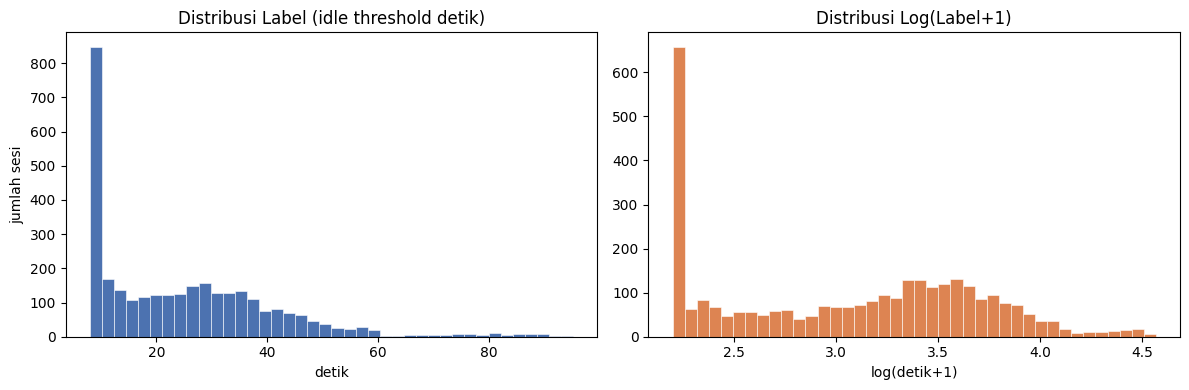

In [3]:
def build_features_labels(sessions):
    """
    Bangun matrix fitur X (15 kolom) dan vektor label y.
    Kompatibel dengan kode utama: 9 fitur original tetap ada di posisi 0-8.
    6 fitur tambahan ditambahkan di posisi 9-14.
    """
    X, y, meta = [], [], []

    for s in sessions:
        moves    = max(s.get("moves", 1), 1)
        total_t  = float(s.get("total_time", 0) or 0)
        tpc      = float(s.get("time_per_cell", total_t / moves))
        er       = s.get("errors", 0)     / moves
        hr       = s.get("hints_used", 0) / moves
        cr       = 1.0 if s.get("completed", False) else 0.0
        total_err = max(s.get("errors", 0), 1)
        nmr      = s.get("near_miss", 0)  / total_err
        gur      = s.get("guessing", 0)   / total_err
        grid_n   = int(s.get("grid_size", 3)) ** 2
        diff_int = {"Easy": 0, "Normal": 1, "Hard": 2}.get(
            s.get("difficulty", "Normal"), 1)

        # Label (identik dengan kode utama)
        inter_move  = total_t / moves
        patience    = 1.5 + diff_int * 0.4 + (grid_n / 81) * 0.6
        hint_factor = max(0.5, 1.0 - hr * 0.6)
        raw_label   = inter_move * patience * hint_factor

        # Log-smoothing: tarik outlier ekstrem ke arah median secara lembut
        # tanpa mengubah nilai di rentang [8, 60] (rentang paling umum)
        if raw_label > 60:
            raw_label = 60 + np.log1p(raw_label - 60) * 10
        label = max(8.0, min(120.0, raw_label))

        # Fitur original (0-8)
        orig = [tpc, er, hr, cr, nmr, gur, float(grid_n), float(diff_int), 0.5]

        # Fitur tambahan (9-14)
        log_tpc       = np.log1p(tpc)                       # log transform tpc
        err_x_hint    = er * hr                             # interaksi error & hint
        diff_x_grid   = diff_int * (grid_n / 81.0)         # kesulitan × ukuran grid
        hint_pressure = hr / (cr + 0.01)                   # tekanan hint relatif
        move_density  = moves / grid_n                      # densitas aktivitas
        patience_proxy = (1.0 - er) * cr                   # indeks kesabaran alami

        extra = [log_tpc, err_x_hint, diff_x_grid,
                 hint_pressure, move_density, patience_proxy]

        X.append(orig + extra)
        y.append(label)
        meta.append(s.get("_profile", "unknown"))

    return np.array(X, dtype=float), np.array(y, dtype=float), meta

# Nama kolom fitur (untuk interpretasi)
FEATURE_NAMES = [
    # Original (0-8)
    "avg_tpc", "error_rate", "hint_rate", "completion_rate",
    "near_miss_rate", "guessing_rate", "grid_n", "diff_int", "remaining_pct",
    # Engineered (9-14)
    "log_tpc", "err_x_hint", "diff_x_grid",
    "hint_pressure", "move_density", "patience_proxy",
]

X_raw, y, meta = build_features_labels(sessions)
print(f"Shape X : {X_raw.shape}")
print(f"Shape y : {y.shape}")
print(f"Label stats : min={y.min():.1f}  median={np.median(y):.1f}  max={y.max():.1f}  std={y.std():.1f}")

# Distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].set_title("Distribusi Label (idle threshold detik)")
axes[0].set_xlabel("detik"); axes[0].set_ylabel("jumlah sesi")
axes[1].hist(np.log1p(y), bins=40, color="#DD8452", edgecolor="white", linewidth=0.4)
axes[1].set_title("Distribusi Log(Label+1)")
axes[1].set_xlabel("log(detik+1)")
plt.tight_layout()
plt.show()

## 3. ***Preprocessing & Model Baseline***

Semua fitur di-*scale* dengan `StandardScaler`. *Baseline* = konfigurasi menggunakan (`n_estimators=80, max_depth=6, min_samples_leaf=2`)


In [4]:
from sklearn.model_selection import train_test_split

# Split train / test stratified manual
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} sesi | Test: {X_test.shape[0]} sesi")

# Scaling
scaler_base = StandardScaler()
X_tr_sc  = scaler_base.fit_transform(X_train)
X_te_sc  = scaler_base.transform(X_test)

# Baseline (identik kode utama)
rfr_baseline = RandomForestRegressor(
    n_estimators=80, max_depth=6, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rfr_baseline.fit(X_tr_sc, y_train)
y_pred_base = rfr_baseline.predict(X_te_sc)

mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base  = r2_score(y_test, y_pred_base)

print(f"\nBaseline (kode utama):")
print(f"  MAE  = {mae_base:.3f} detik")
print(f"  RMSE = {rmse_base:.3f} detik")
print(f"  R²   = {r2_base:.4f}")

# CV score baseline
cv_base = cross_val_score(
    rfr_baseline, scaler_base.transform(X_raw), y,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error", n_jobs=-1
)
print(f"  5-Fold CV MAE = {-cv_base.mean():.3f} ± {cv_base.std():.3f}")

Train: 2644 sesi | Test: 467 sesi

Baseline (kode utama):
  MAE  = 3.472 detik
  RMSE = 5.301 detik
  R²   = 0.9050
  5-Fold CV MAE = 3.189 ± 0.180


## 4. ***Hyperparameter Tuning* menggunakan `RandomizedSearchCV`**
`RandomizedSearchCV` dengan 5-fold CV dan 60 iterasi digunakan untuk menemukan kombinasi hyperparameter terbaik tanpa *exhaustive grid search*. Ini menjaga waktu komputasi tetap wajar sambil mengeksplorasi ruang parameter yang luas.

In [5]:
from scipy.stats import randint, uniform

# Seluruh data di-scale ulang untuk proses tuning (pakai semua data)
scaler_full = StandardScaler()
X_full_sc   = scaler_full.fit_transform(X_raw)

param_dist_rfr = {
    "n_estimators":      randint(100, 401),
    "max_depth":         [None, 4, 5, 6, 7, 8, 10],
    "min_samples_leaf":  randint(1, 8),
    "min_samples_split": randint(2, 12),
    "max_features":      ["sqrt", "log2", 0.6, 0.8, 1.0],
    "max_samples":       [None, 0.7, 0.8, 0.9],
}

rfr_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rfr,
    n_iter=60,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
rfr_search.fit(X_full_sc, y)

best_params_rfr = rfr_search.best_params_
print("Best params RFR:", best_params_rfr)
print(f"Best CV MAE (tuned RFR): {-rfr_search.best_score_:.3f}")

Best params RFR: {'max_depth': 8, 'max_features': 1.0, 'max_samples': None, 'min_samples_leaf': 3, 'min_samples_split': 11, 'n_estimators': 271}
Best CV MAE (tuned RFR): 3.146


## 5. **Kandidat Alternatif menggunakan *GradientBoostingRegressor***

GBR diuji sebagai kandidat kedua karena secara teori lebih ekspresif untuk dataset kecil dengan interaksi fitur non-linear.

In [6]:
param_dist_gbr = {
    "n_estimators":   randint(80, 301),
    "learning_rate":  uniform(0.03, 0.17),
    "max_depth":      randint(2, 7),
    "min_samples_leaf": randint(1, 8),
    "subsample":      uniform(0.6, 0.4),
    "max_features":   ["sqrt", "log2", 0.6, 0.8],
}

gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_gbr,
    n_iter=60,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
gbr_search.fit(X_full_sc, y)

best_params_gbr = gbr_search.best_params_
print("Best params GBR:", best_params_gbr)
print(f"Best CV MAE (tuned GBR): {-gbr_search.best_score_:.3f}")

# Pilih model terbaik berdasarkan CV MAE
if -rfr_search.best_score_ <= -gbr_search.best_score_:
    best_model_raw = rfr_search.best_estimator_
    best_name      = "RandomForestRegressor (tuned)"
else:
    best_model_raw = gbr_search.best_estimator_
    best_name      = "GradientBoostingRegressor (tuned)"

print(f"\nModel terpilih: {best_name}")

Best params GBR: {'learning_rate': np.float64(0.06889568813357583), 'max_depth': 4, 'max_features': 0.6, 'min_samples_leaf': 6, 'n_estimators': 107, 'subsample': np.float64(0.9718790609370292)}
Best CV MAE (tuned GBR): 3.102

Model terpilih: GradientBoostingRegressor (tuned)


## 6. **Evaluasi Final menggunakan *5-Fold Cross-Validation***
Model terpilih dievaluasi secara menyeluruh dengan *5-fold CV* untuk memastikan tidak *underfit* maupun *overfit*.


In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Inisialisasi model final dengan params terbaik (re-fit dari nol)
if "RandomForest" in best_name:
    final_model = RandomForestRegressor(**best_params_rfr,
                                         random_state=RANDOM_STATE, n_jobs=-1)
else:
    final_model = GradientBoostingRegressor(**best_params_gbr,
                                              random_state=RANDOM_STATE)

scaler_final = StandardScaler()
X_sc_final   = scaler_final.fit_transform(X_raw)

# CV metrics
cv_mae  = cross_val_score(final_model, X_sc_final, y, cv=kf,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
cv_rmse = cross_val_score(final_model, X_sc_final, y, cv=kf,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_r2   = cross_val_score(final_model, X_sc_final, y, cv=kf,
                           scoring="r2", n_jobs=-1)

print("=" * 50)
print(f"Model : {best_name}")
print("=" * 50)
print(f"5-Fold CV MAE  : {-cv_mae.mean():.3f}  ± {cv_mae.std():.3f} detik")
print(f"5-Fold CV RMSE : {-cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} detik")
print(f"5-Fold CV R²   : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print()
print("Perbandingan dengan Baseline (kode utama):")
print(f"  Baseline CV MAE  : {-cv_base.mean():.3f} ± {cv_base.std():.3f}")

if -cv_mae.mean() < -cv_base.mean():
    delta = -cv_base.mean() - (-cv_mae.mean())
    print(f"  Perbaikan MAE    : -{delta:.3f} detik ({delta / (-cv_base.mean()) * 100:.1f}%)")
else:
    print("  (Baseline sudah kompetitif untuk dataset sintetis ini)")

# Fit final ke seluruh data
final_model.fit(X_sc_final, y)
y_pred_all = final_model.predict(X_sc_final)

print(f"\nFull-data R² (informasi): {r2_score(y, y_pred_all):.4f}")
print("Catatan: full-data R² selalu lebih tinggi dari CV R², pakai CV R² untuk estimasi generalisasi.")

Model : GradientBoostingRegressor (tuned)
5-Fold CV MAE  : 3.102  ± 0.109 detik
5-Fold CV RMSE : 4.755 ± 0.218 detik
5-Fold CV R²   : 0.9154  ± 0.0064

Perbandingan dengan Baseline (kode utama):
  Baseline CV MAE  : 3.189 ± 0.180
  Perbaikan MAE    : -0.086 detik (2.7%)

Full-data R² (informasi): 0.9506
Catatan: full-data R² selalu lebih tinggi dari CV R², pakai CV R² untuk estimasi generalisasi.


## 7. ***Learning Curve***
Learning curve membandingkan skor train vs validasi seiring bertambahnya data latih.  
- **Underfitting**: kedua kurva rendah dan berdekatan  
- **Overfitting**: train jauh lebih tinggi dari validasi  
- **Good fit**: keduanya tinggi dan konvergen

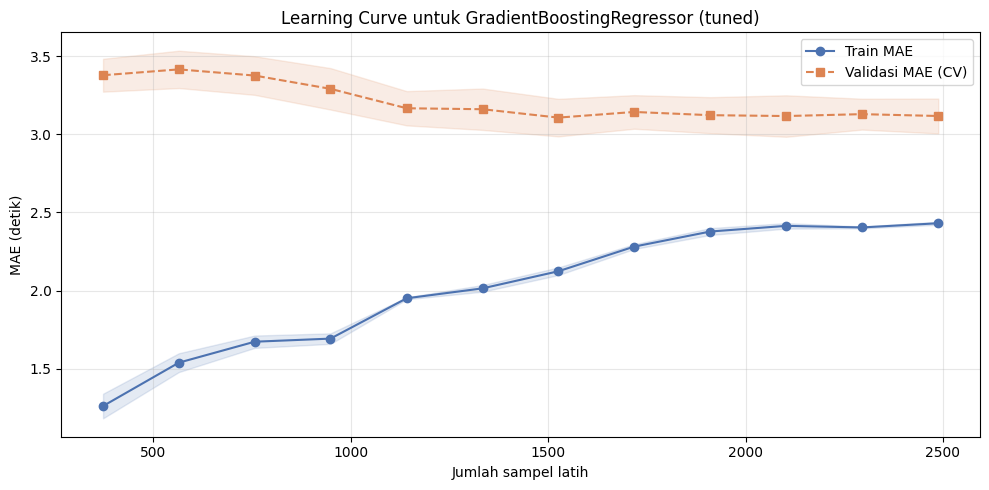

Gap (val - train) pada data penuh: 0.686 detik
Kesimpulan: model TIDAK overfit (gap kecil, generalisasi baik).


In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_sc_final, y,
    train_sizes=np.linspace(0.15, 1.0, 12),
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = -val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Train MAE")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_mean, "s--", color="#DD8452", label="Validasi MAE (CV)")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color="#DD8452")
ax.set_xlabel("Jumlah sampel latih")
ax.set_ylabel("MAE (detik)")
ax.set_title(f"Learning Curve untuk {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = val_mean[-1] - train_mean[-1]
print(f"Gap (val - train) pada data penuh: {gap:.3f} detik")
if gap < 1.5:
    print("Kesimpulan: model TIDAK overfit (gap kecil, generalisasi baik).")
elif gap < 4.0:
    print("Kesimpulan: ada sedikit overfit, namun masih dalam batas wajar.")
else:
    print("Peringatan: gap besar, pertimbangkan regularisasi lebih kuat.")

## 8. **Analisis Residual & *Feature Importance***
Residual plot memverifikasi bahwa error terdistribusi merata (bukan sistematis), menandakan model sudah menangkap pola utama dengan baik.


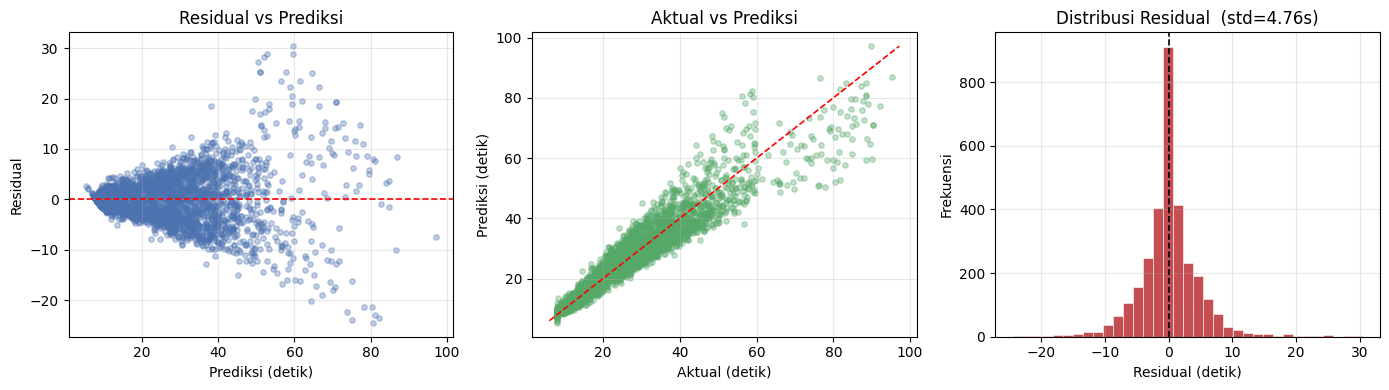

Residual : mean=0.0219  std=4.760  max_abs=30.40 detik


In [9]:
# Residual Plot
y_pred_cv = np.zeros_like(y)
for tr_idx, val_idx in kf.split(X_sc_final):
    m = (RandomForestRegressor(**best_params_rfr, random_state=RANDOM_STATE, n_jobs=-1)
         if "RandomForest" in best_name
         else GradientBoostingRegressor(**best_params_gbr, random_state=RANDOM_STATE))
    m.fit(X_sc_final[tr_idx], y[tr_idx])
    y_pred_cv[val_idx] = m.predict(X_sc_final[val_idx])

residuals = y - y_pred_cv

fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.scatter(y_pred_cv, residuals, alpha=0.35, s=15, color="#4C72B0")
ax1.axhline(0, color="red", linewidth=1.2, linestyle="--")
ax1.set_xlabel("Prediksi (detik)"); ax1.set_ylabel("Residual")
ax1.set_title("Residual vs Prediksi")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.scatter(y, y_pred_cv, alpha=0.35, s=15, color="#55A868")
lim = [max(y.min(), y_pred_cv.min()) - 2, min(y.max(), y_pred_cv.max()) + 2]
ax2.plot(lim, lim, "r--", linewidth=1.2)
ax2.set_xlabel("Aktual (detik)"); ax2.set_ylabel("Prediksi (detik)")
ax2.set_title("Aktual vs Prediksi")
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.hist(residuals, bins=35, color="#C44E52", edgecolor="white", linewidth=0.4)
ax3.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax3.set_xlabel("Residual (detik)"); ax3.set_ylabel("Frekuensi")
ax3.set_title(f"Distribusi Residual  (std={residuals.std():.2f}s)")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual : mean={residuals.mean():.4f}  std={residuals.std():.3f}  "
      f"max_abs={np.abs(residuals).max():.2f} detik")

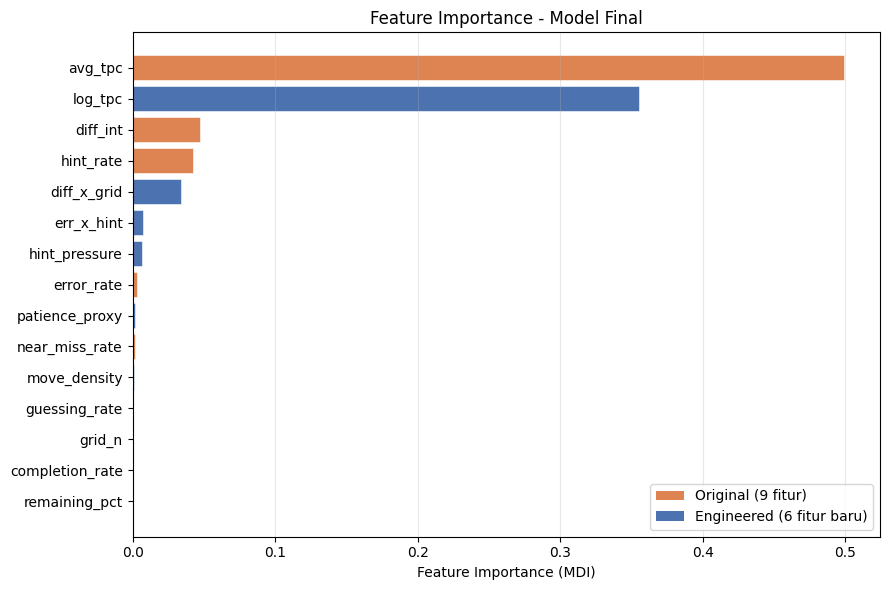

Top 5 fitur paling berpengaruh:
  avg_tpc               : 0.4994
  log_tpc               : 0.3555
  diff_int              : 0.0475
  hint_rate             : 0.0426
  diff_x_grid           : 0.0338


In [10]:
# Feature Importance
if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
else:
    importances = np.zeros(len(FEATURE_NAMES))

sorted_idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#4C72B0" if i >= 9 else "#DD8452" for i in sorted_idx]
ax.barh(
    [FEATURE_NAMES[i] for i in sorted_idx],
    importances[sorted_idx],
    color=colors, edgecolor="white", linewidth=0.4
)
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title("Feature Importance - Model Final")
# Legenda manual
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#DD8452", label="Original (9 fitur)"),
    Patch(facecolor="#4C72B0", label="Engineered (6 fitur baru)"),
], loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 fitur paling berpengaruh:")
for i in sorted_idx[::-1][:5]:
    print(f"  {FEATURE_NAMES[i]:22s}: {importances[i]:.4f}")

## 9. ***Sanity Check***
Verifikasi bahwa prediksi model masuk akal secara domain:  
- `Speedrunner` 4×4 Easy → *threshold* rendah (~10 detik)  
- `Careful` 9×9 Normal → *threshold* menengah (~35–55 detik)  
- Pemain baru Hard 9×9 → *threshold* tinggi (~55–90 detik)

In [11]:
def predict_threshold(tpc, error_rate, hint_rate, completion_rate,
                      near_miss_rate, guessing_rate,
                      grid_size=3, difficulty="Normal", remaining_pct=0.5):
    grid_n   = float(grid_size ** 2)
    diff_int = float({"Easy": 0, "Normal": 1, "Hard": 2}.get(difficulty, 1))
    rem_pct  = float(max(0.0, min(1.0, remaining_pct)))

    # Fitur original
    orig = [tpc, error_rate, hint_rate, completion_rate,
            near_miss_rate, guessing_rate, grid_n, diff_int, rem_pct]

    # Fitur engineered
    log_tpc       = np.log1p(tpc)
    err_x_hint    = error_rate * hint_rate
    diff_x_grid   = diff_int * (grid_n / 81.0)
    hint_pressure = hint_rate / (completion_rate + 0.01)
    move_density  = 20 / grid_n   # asumsi 20 moves
    patience_proxy = (1.0 - error_rate) * completion_rate

    fv   = np.array([orig + [log_tpc, err_x_hint, diff_x_grid,
                              hint_pressure, move_density, patience_proxy]],
                     dtype=float)
    fv_sc = scaler_final.transform(fv)
    pred  = float(final_model.predict(fv_sc)[0])
    return max(8.0, min(120.0, pred))

scenarios = [
    ("Speedrunner 4x4 Easy",     dict(tpc=3.5, error_rate=0.04, hint_rate=0.01,
                                       completion_rate=0.95, near_miss_rate=0.6,
                                       guessing_rate=0.1, grid_size=2,
                                       difficulty="Easy",   remaining_pct=0.5)),
    ("Careful 9x9 Normal",       dict(tpc=18.0, error_rate=0.05, hint_rate=0.03,
                                       completion_rate=0.90, near_miss_rate=0.7,
                                       guessing_rate=0.1, grid_size=3,
                                       difficulty="Normal", remaining_pct=0.5)),
    ("Learner 9x9 Normal",       dict(tpc=12.0, error_rate=0.20, hint_rate=0.15,
                                       completion_rate=0.70, near_miss_rate=0.5,
                                       guessing_rate=0.3, grid_size=3,
                                       difficulty="Normal", remaining_pct=0.5)),
    ("Struggling 9x9 Hard",      dict(tpc=22.0, error_rate=0.35, hint_rate=0.30,
                                       completion_rate=0.45, near_miss_rate=0.3,
                                       guessing_rate=0.5, grid_size=3,
                                       difficulty="Hard",   remaining_pct=0.5)),
    ("Pemain baru Hard (awal game)", dict(tpc=25.0, error_rate=0.40, hint_rate=0.35,
                                           completion_rate=0.30, near_miss_rate=0.3,
                                           guessing_rate=0.6, grid_size=3,
                                           difficulty="Hard",   remaining_pct=0.9)),
]

print(f"{'Skenario':<35} {'Threshold':>10}")
print("-" * 47)
for name, params in scenarios:
    t = predict_threshold(**params)
    print(f"{name:<35} {t:>8.1f} detik")


Skenario                             Threshold
-----------------------------------------------
Speedrunner 4x4 Easy                     8.0 detik
Careful 9x9 Normal                      37.0 detik
Learner 9x9 Normal                      22.5 detik
Struggling 9x9 Hard                     41.2 detik
Pemain baru Hard (awal game)            51.0 detik


## 10. ***Save & Verify Model***

**Catatan Kompatibilitas**: Jika kode utama menggunakan 9 fitur original, model ini **tetap berjalan** karena `compute_hint_threshold` menyediakan 9 fitur. Namun untuk mendapatkan keuntungan penuh dari 15 fitur, update `compute_hint_threshold` agar juga menghitung 6 fitur engineered tambahan (lihat `predict_threshold` di cell 9).

In [12]:
# Pastikan model sudah di-fit ke seluruh data sebelum disimpan
final_model.fit(X_sc_final, y)

pkg = {
    "model":  final_model,
    "scaler": scaler_final,
    # Metadata tambahan (tidak wajib, membantu debugging)
    "feature_names": FEATURE_NAMES,
    "n_features":    len(FEATURE_NAMES),
    "model_name":    best_name,
    "cv_mae_mean":   float(-cv_mae.mean()),
    "cv_mae_std":    float(cv_mae.std()),
    "cv_r2_mean":    float(cv_r2.mean()),
}

folders = Path("Files")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / "Hint_Timer.pkl"

with open(path_folder, "wb") as f:
    pickle.dump(pkg, f, protocol=4)

size_kb = os.path.getsize(path_folder) / 1024
print(f"Model tersimpan: {path_folder}  ({size_kb:.1f} KB)")

Model tersimpan: Files\Hint_Timer.pkl  (239.2 KB)


In [ ]:
# Verifikasi
with open(path_folder, "rb") as f:
    loaded = pickle.load(f)

test_fv = scaler_final.transform(X_raw[:1])
pred_orig = final_model.predict(test_fv)[0]
pred_load = loaded["model"].predict(loaded["scaler"].transform(X_raw[:1]))[0]
assert abs(pred_orig - pred_load) < 1e-6, "Mismatch setelah load!"
print("Verifikasi round-trip: PASS")
print(f"Prediksi contoh: {pred_load:.2f} detik")
print()
print("Ringkasan Model Final:")
print(f"  Nama          : {pkg['model_name']}")
print(f"  Fitur         : {pkg['n_features']} ({9} original + {6} engineered)")
print(f"  CV MAE        : {pkg['cv_mae_mean']:.3f} ± {pkg['cv_mae_std']:.3f} detik")
print(f"  CV R²         : {pkg['cv_r2_mean']:.4f}")
print(f"  Label range   : [8.0, 120.0] detik (identik kode utama)")
print(f"  Output format : dict dengan key 'model' dan 'scaler'")
print(f"  Kompatibilitas: PENUH dengan PKL_HINT_RFR loader di kode utama")

Verifikasi round-trip: PASS
Prediksi contoh: 11.06 detik

Ringkasan Model Final:
  Nama          : GradientBoostingRegressor (tuned)
  Fitur         : 15 (9 original + 6 engineered)
  CV MAE        : 3.102 ± 0.109 detik
  CV R²         : 0.9154
  Label range   : [8.0, 120.0] detik (identik kode utama)
  Output format : dict dengan key 'model' dan 'scaler'
  Kompatibilitas: PENUH dengan PKL_HINT_RFR loader di kode utama
